**#Imports**

In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import json

**#Load Dataset**

In [2]:
train_dir = r"D:\major project\crop_disease_prediction_v2\dataset\train"
valid_dir = r"D:\major project\crop_disease_prediction_v2\dataset\valid"

training_set = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=(128,128),
    batch_size=32,
    label_mode="categorical"
)

validation_set = tf.keras.utils.image_dataset_from_directory(
    valid_dir,
    image_size=(128,128),
    batch_size=32,
    label_mode="categorical"
)

Found 70295 files belonging to 38 classes.
Found 17572 files belonging to 38 classes.


**#Save Class Names**

In [3]:
class_names = training_set.class_names

with open("class_names.json","w") as f:
    json.dump(class_names,f)

**#Build CNN Model**

In [4]:
from tensorflow.keras.layers import Dense,Conv2D,MaxPool2D,Flatten,Dropout
from tensorflow.keras.models import Sequential

model = Sequential()

model.add(Conv2D(32,3,padding='same',activation='relu',input_shape=[128,128,3]))
model.add(Conv2D(32,3,activation='relu'))
model.add(MaxPool2D(2,2))

model.add(Conv2D(64,3,padding='same',activation='relu'))
model.add(Conv2D(64,3,activation='relu'))
model.add(MaxPool2D(2,2))

model.add(Conv2D(128,3,padding='same',activation='relu'))
model.add(Conv2D(128,3,activation='relu'))
model.add(MaxPool2D(2,2))

model.add(Conv2D(256,3,padding='same',activation='relu'))
model.add(Conv2D(256,3,activation='relu'))
model.add(MaxPool2D(2,2))

model.add(Conv2D(512,3,padding='same',activation='relu'))
model.add(Conv2D(512,3,activation='relu'))
model.add(MaxPool2D(2,2))

model.add(Dropout(0.25))

model.add(Flatten())

model.add(Dense(1500,activation='relu'))

model.add(Dropout(0.4))

model.add(Dense(38,activation='softmax'))

D:\major project\crop_disease_prediction_v2\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


**#Compile Model**

In [5]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

**#Train Model**

In [6]:
history = model.fit(
    training_set,
    validation_data=validation_set,
    epochs=10
)

Epoch 1/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 4893s 2s/step - accuracy: 0.5959 - loss: 1.3742 - val_accuracy: 0.8275 - val_loss: 0.5502
Epoch 2/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 1370s 624ms/step - accuracy: 0.8518 - loss: 0.4679 - val_accuracy: 0.9146 - val_loss: 0.2717
Epoch 3/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 1214s 553ms/step - accuracy: 0.9125 - loss: 0.2718 - val_accuracy: 0.9167 - val_loss: 0.2599
Epoch 4/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 1158s 527ms/step - accuracy: 0.9393 - loss: 0.1863 - val_accuracy: 0.9316 - val_loss: 0.2102
Epoch 5/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 1395s 635ms/step - accuracy: 0.9543 - loss: 0.1398 - val_accuracy: 0.9415 - val_loss: 0.1847
Epoch 6/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 1346s 613ms/step - accuracy: 0.9655 - loss: 0.1054 - val_accuracy: 0.9413 - val_loss: 0.1841
Epoch 7/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 1981s 902ms/step - accuracy: 0.9711 - loss: 0.0906 - val_accuracy: 0.9551 - val_loss: 0.1367
Epoch 8/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 1545s 703ms/step

**#Evaluate**

In [7]:
train_loss,train_acc = model.evaluate(training_set)
val_loss,val_acc = model.evaluate(validation_set)

print("Train Accuracy:", train_acc)
print("Validation Accuracy:", val_acc)

2197/2197 ━━━━━━━━━━━━━━━━━━━━ 284s 129ms/step - accuracy: 0.9822 - loss: 0.0578
550/550 ━━━━━━━━━━━━━━━━━━━━ 58s 105ms/step - accuracy: 0.9552 - loss: 0.1597
Train Accuracy: 0.9821751117706299
Validation Accuracy: 0.9552128314971924


**#Save Model**

In [8]:
model.save("plant_disease_model_final.keras")

**#Save History**

In [9]:
with open("training_history.json","w") as f:
    json.dump(history.history,f)

**#Plot Graph**

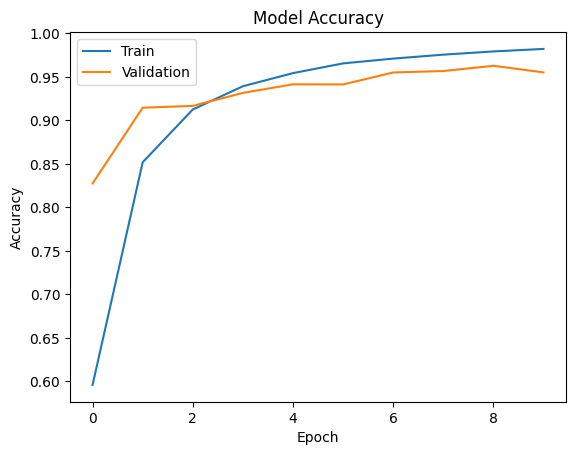

In [10]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train","Validation"])

plt.show()